# Lab Assignment 6: Feature Selection on Heart Disease Dataset

Feature selection involves picking the set of features that are most relevant to the target variable. This helps in reducing the complexity of your model, as well as minimizing the resources required for training and inference. This has greater effect in production models where you maybe dealing with terabytes of data or serving millions of requests.

In this notebook, you will run through the different techniques in performing feature selection on the Heart Disease Dataset. Most of the modules will come from scikit-learn, one of the most commonly used machine learning libraries. It features various machine learning algorithms and has built-in implementations of different feature selection methods. Using these, you will be able to compare which method works best for this particular dataset.

## Imports

In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectKBest, SelectFromModel, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('heart.csv')
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Load the dataset

We've already downloaded the CSV in your workspace. Run the cell below to load it in the lab environment and inspect its properties.

In [29]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Print datatypes
print(df.dtypes)

# Describe columns
df.describe(include='all')

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [30]:
df = pd.read_csv('heart.csv')
df = df.drop_duplicates()
print(df.shape)  # should be lower than 1025

(302, 14)


In [31]:
# Preview the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Remove Unwanted Features

You can remove features that are not needed when making predictions. The column `Unnamed: 32` has `NaN` values for all rows. Moreover, the `id` is just an arbitrary number assigned to patients and has nothing to do with the diagnosis. Hence, you can remove them from the dataset.

In [32]:
# Check if there are null values in any of the columns. You will see `Unnamed: 32` has a lot.
df.isna().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [33]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Model Performance

Next, split the dataset into feature vectors `X` and target vector (diagnosis) `Y` to fit a [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). You will then compare the performance of each feature selection technique, using [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [roc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score), [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score), [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score) and [f1-score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score) as evaluation metrics.

In [34]:
# Split feature and target vectors
X = df.drop("target", axis=1)
Y = df["target"]

### Fit the Model and Calculate Metrics

You will define helper functions to train your model and use the scikit-learn modules to evaluate your results.

In [35]:
def fit_model(X, Y):
    model = RandomForestClassifier(criterion='entropy', random_state=47)
    model.fit(X, Y)
    return model

In [36]:
def calculate_metrics(model, X_test_scaled, Y_test):
    y_predict_r = model.predict(X_test_scaled)
    acc = accuracy_score(Y_test, y_predict_r)
    roc = roc_auc_score(Y_test, y_predict_r)
    prec = precision_score(Y_test, y_predict_r)
    rec = recall_score(Y_test, y_predict_r)
    f1 = f1_score(Y_test, y_predict_r)
    return acc, roc, prec, rec, f1

In [37]:
def train_and_get_metrics(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = fit_model(X_train_scaled, Y_train)
    acc, roc, prec, rec, f1 = calculate_metrics(model, X_test_scaled, Y_test)
    return acc, roc, prec, rec, f1

In [38]:
def evaluate_model_on_features(X, Y):
    acc, roc, prec, rec, f1 = train_and_get_metrics(X, Y)
    display_df = pd.DataFrame([[acc, roc, prec, rec, f1, X.shape[1]]], columns=["Accuracy", "ROC", "Precision", "Recall", "F1 Score", "Feature Count"])
    return display_df

Now you can train the model with all features included then calculate the metrics. This will be your baseline and you will compare this to the next outputs when you do feature selection.

In [39]:
# Calculate evaluation metrics
all_features_eval_df = evaluate_model_on_features(X, Y)
all_features_eval_df.index = ['All features']
results = all_features_eval_df
results.head()

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13


## Correlation Matrix

It is a good idea to calculate and visualize the correlation matrix of a data frame to see which features have high correlation. You can do that with just a few lines as shown below. The Pandas [corr()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) method computes the Pearson correlation by default and you will plot it with Matlab PyPlot and Seaborn. The darker blue boxes show features with high positive correlation while white ones indicate high negative correlation. The diagonals will have 1's because the feature is mapped on to itself.

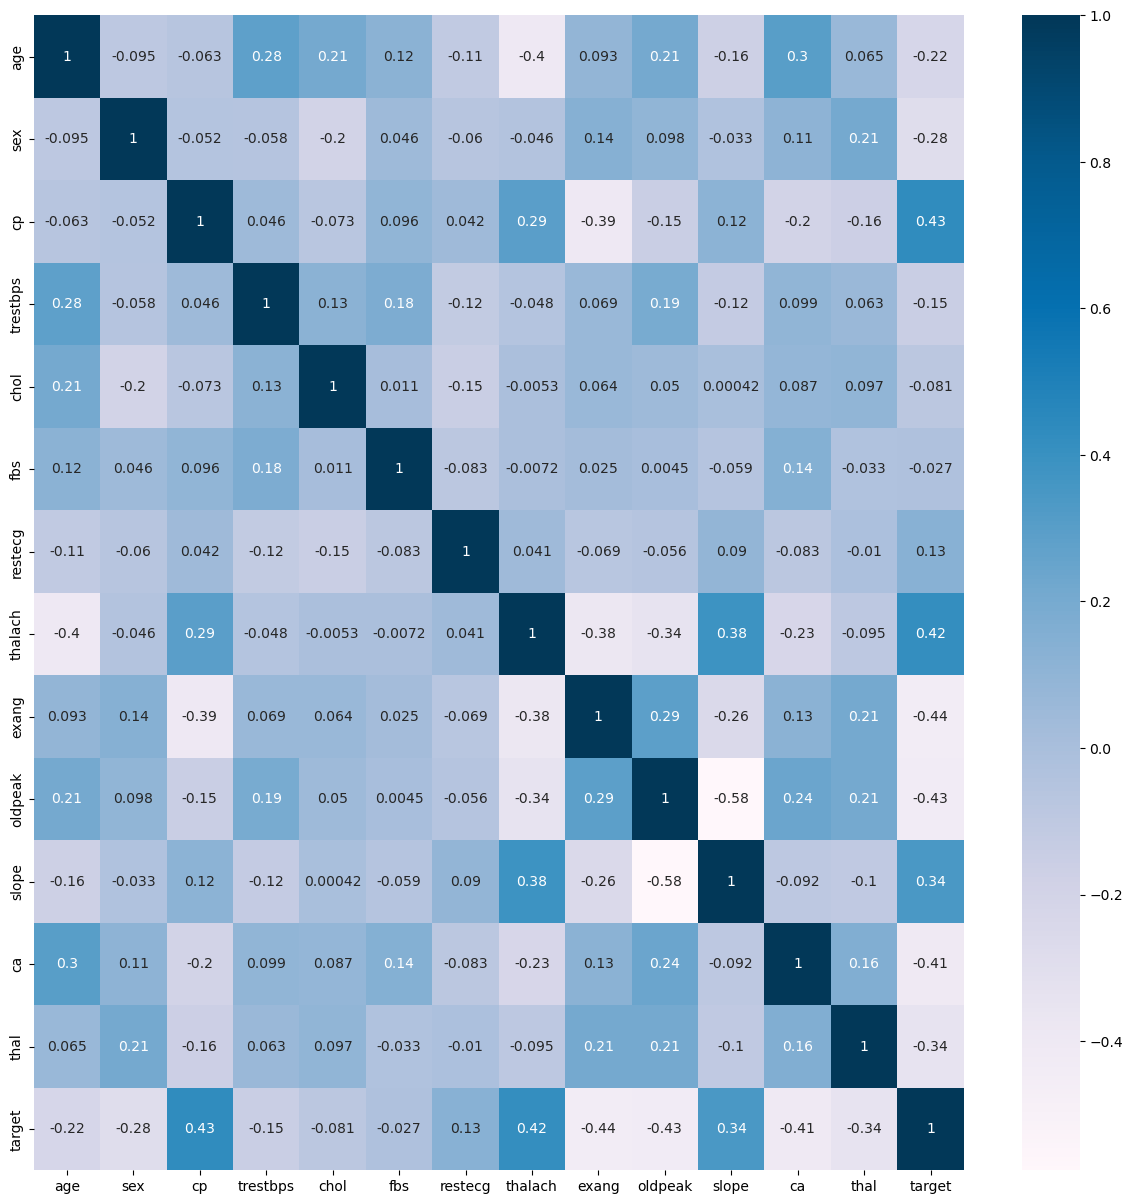

In [40]:
plt.figure(figsize=(15,15))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.PuBu)
plt.show()

## Filter Methods

Let's start feature selection with filter methods. This type of feature selection uses statistical methods to rank a given set of features. Moreover, it does this ranking regardless of the model you will be training on (i.e. you only need the feature values). When using these, it is important to note the types of features and target variable you have. Here are a few examples:

* Pearson Correlation (numeric features - numeric target, *exception: when target is 0/1 coded*)
* ANOVA f-test (numeric features - categorical target)
* Chi-squared (categorical features - categorical target)

Let's use some of these in the next cells.

### Correlation with the target variable

Let's start by determining which features are strongly correlated with the diagnosis (i.e. the target variable). Since we have numeric features and our target, although categorical, is 0/1 coded, we can use Pearson correlation to compute the scores for each feature. This is also categorized as *supervised* feature selection because we're taking into account the relationship of each feature with the target variable. Moreover, since only one variable's relationship to the target is taken at a time, this falls under *univariate feature selection*.

In [41]:
cor_target = abs(cor["target"])
relevant_features = cor_target[cor_target > 0.2]
names = [index for index, value in relevant_features.items()]
names.remove('target')
print(names)

['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


Now try training the model again but only with the features in the columns you just gathered. You can observe that there is an improvement in the metrics compared to the model you trained earlier.

In [42]:
# Evaluate the model with new features
strong_features_eval_df = evaluate_model_on_features(df[names], Y)
strong_features_eval_df.index = ['Strong features']
results = pd.concat([results, strong_features_eval_df])
results.head()

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9


### Correlation with other features

You will now eliminate features which are highly correlated with each other. This helps remove redundant features thus resulting in a simpler model. Since the scores are calculated regardless of the target variable, this can be categorized under *unsupervised* feature selection.

For this, you will plot the correlation matrix of the features selected previously. Let's first visualize the correlation matrix again.

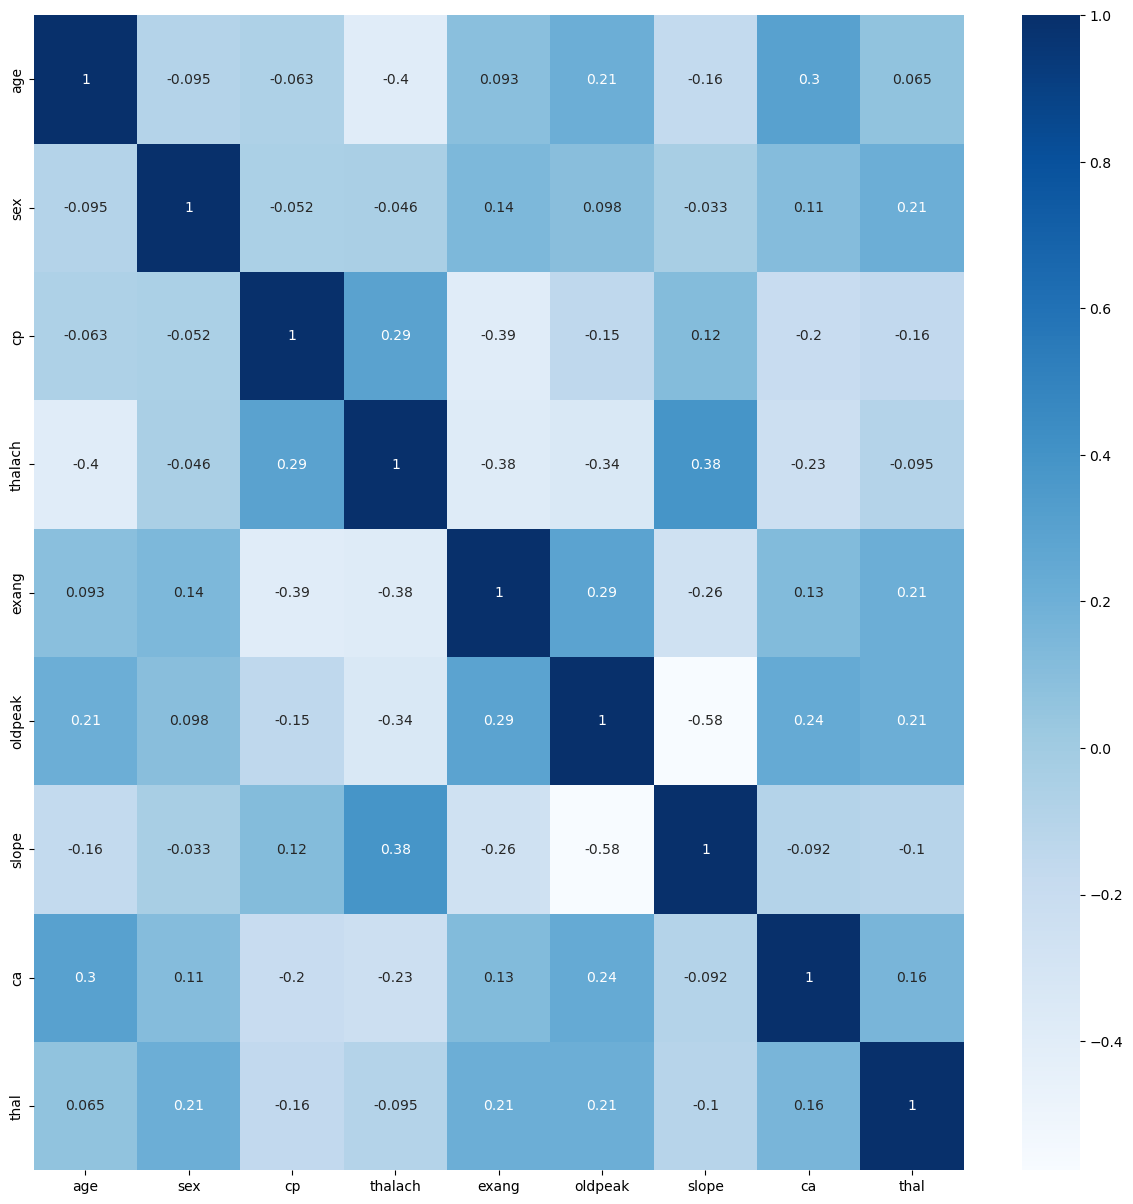

In [43]:
# Set figure size
plt.figure(figsize=(15,15))
new_corr = df[names].corr()
sns.heatmap(new_corr, annot=True, cmap=plt.cm.Blues)
plt.show()

You will see that thalach and oldpeak are highly correlated to each other. You can retain the other features and remove these two as they are redundant.
You will now evaluate the model on the features selected based on your observations. The metrics show similar values as when it was using 9 features (Strong features). This indicates that thalach and oldpeak were somewhat redundant and removing them did not significantly affect model performance.


In [44]:
# Remove the features with high correlation to other features
# Remove highly correlated features based on heatmap observation
subset_feature_corr_names = [x for x in names if x not in ['thalach', 'oldpeak']]
subset_feature_eval_df = evaluate_model_on_features(df[subset_feature_corr_names], Y)
subset_feature_eval_df.index = ['Subset features']
results = pd.concat([results, subset_feature_eval_df])
results.head(10)

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9
Subset features,0.803279,0.796537,0.783784,0.878788,0.828571,7


*Bonus challenge (not required): Look back again at the correlation matrix at the start of this section and see if you can remove other highly correlated features. You can remove at least one more and arrive at the same model performance.*

### Univariate Selection with Sci-Kit Learn

Sci-kit learn offers more filter methods in its feature selection module. Moreover, it also has convenience methods for how you would like to filter the features. You can see the available options here in the [official docs](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection). 

For this exercise, you will compute the ANOVA F-values to select the top 20 features using `SelectKBest()`.

In [45]:
def univariate_selection():
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    selector = SelectKBest(f_classif, k=10)
    X_new = selector.fit_transform(X_train_scaled, Y_train)
    feature_idx = selector.get_support()
    for name, included in zip(df.drop("target", axis=1).columns, feature_idx):
        print("%s: %s" % (name, included))
    feature_names = df.drop("target", axis=1).columns[feature_idx]
    return feature_names

univariate_feature_names = univariate_selection()
univariate_eval_df = evaluate_model_on_features(df[univariate_feature_names], Y)
univariate_eval_df.index = ['F-test']
results = pd.concat([results, univariate_eval_df])
results.head(10)

age: True
sex: True
cp: True
trestbps: True
chol: False
fbs: False
restecg: False
thalach: True
exang: True
oldpeak: True
slope: True
ca: True
thal: True


,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9
Subset features,0.803279,0.796537,0.783784,0.878788,0.828571,7
F-test,0.836066,0.834957,0.848485,0.848485,0.848485,10


## Wrapper Methods

Wrapper methods use a model to measure the effectiveness of a particular subset of features. As mentioned in class, one approach is to remove or add features sequentially. You can either start with 1 feature and gradually add until no improvement is made (forward selection), or do the reverse (backward selection). That can be done with the [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html#sklearn.feature_selection.SequentialFeatureSelector) class which uses k-fold cross validation scores to decide which features to add or remove. [Recursive Feature Elimination](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html) is similar to backwards elimination but uses feature importance scores to prune the number of features. You can also specify how many features to remove at each iteration of the recursion. Let's use this as the wrapper for our model below.

### Recursive Feature Elimination

You used the **RandomForestClassifier** as the model algorithm for which features should be selected. Now, you will use **Recursive Feature Elimination**, which wraps around the selected model to perform feature selection. This time, you can repeat the same task of selecting the top 20 features using RFE instead of SelectKBest.

In [46]:
RFE?

Init signature:
RFE(
    estimator,
    *,
    n_features_to_select=None,
    step=1,
    verbose=0,
    importance_getter='auto',
)
Docstring:     
Feature ranking with recursive feature elimination.

Given an external estimator that assigns weights to features (e.g., the
coefficients of a linear model), the goal of recursive feature elimination
(RFE) is to select features by recursively considering smaller and smaller
sets of features. First, the estimator is trained on the initial set of
features and the importance of each feature is obtained either through
any specific attribute or callable.
Then, the least important features are pruned from current set of features.
That procedure is recursively repeated on the pruned set until the desired
number of features to select is eventually reached.

Read more in the :ref:`User Guide <rfe>`.

Parameters
----------
estimator : ``Estimator`` instance
    A supervised learning estimator with a ``fit`` method that provides
    information about

In [47]:
def run_rfe():
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = RandomForestClassifier(criterion='entropy', random_state=47)
    rfe = RFE(model, n_features_to_select=8)
    rfe = rfe.fit(X_train_scaled, Y_train)
    feature_names = df.drop("target", axis=1).columns[rfe.get_support()]
    return feature_names

rfe_feature_names = run_rfe()

You will now evaluate the **RandomForestClassifier** on the features selected by RFE. You will see that there is a slight performance drop compared to the previous approaches.

In [48]:
rfe_eval_df = evaluate_model_on_features(df[rfe_feature_names], Y)
rfe_eval_df.index = ['RFE']
results = pd.concat([results, rfe_eval_df])
results.head(10)

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9
Subset features,0.803279,0.796537,0.783784,0.878788,0.828571,7
F-test,0.836066,0.834957,0.848485,0.848485,0.848485,10
RFE,0.836066,0.834957,0.848485,0.848485,0.848485,8


## Embedded Methods

Some models already have intrinsic properties that select the best features when it is constructed. With that, you can simply access these properties to get the scores for each feature. Let's look at some examples in the following sections.

### Feature Importances

**Feature importance** is already built-in in scikit-learn’s tree based models like **RandomForestClassifier**. Once the model is fit, the feature importance is available as a property named **feature_importances_**.

You can use [SelectFromModel](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html) to select features from the trained model based on a given threshold.

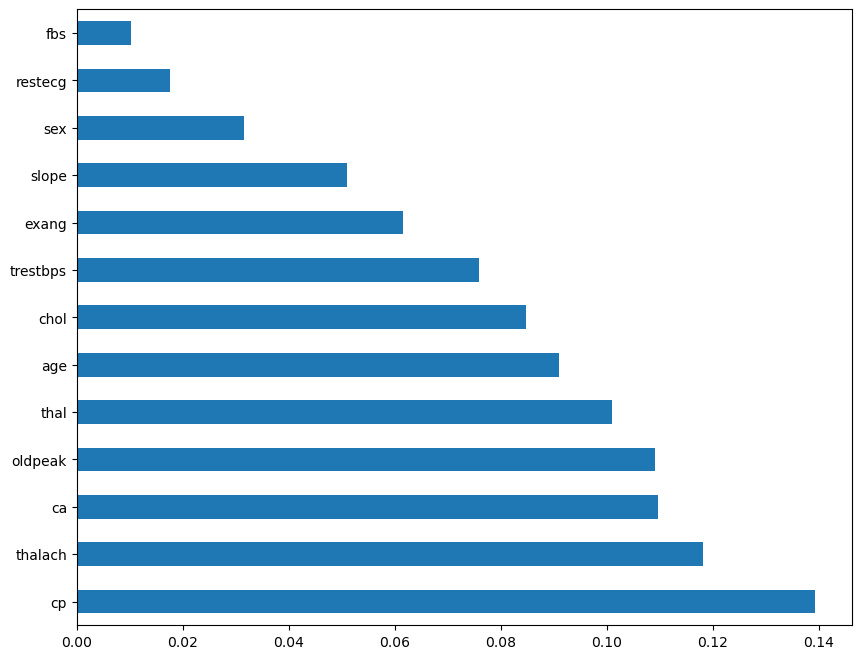

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9
Subset features,0.803279,0.796537,0.783784,0.878788,0.828571,7
F-test,0.836066,0.834957,0.848485,0.848485,0.848485,10
RFE,0.836066,0.834957,0.848485,0.848485,0.848485,8
Feature Importance,0.836066,0.834957,0.848485,0.848485,0.848485,10


In [49]:
def feature_importances_from_tree_based_model_():
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    model = RandomForestClassifier()
    model = model.fit(X_train_scaled, Y_train)
    plt.figure(figsize=(10, 8))
    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    feat_importances.sort_values(ascending=False).plot(kind='barh')
    plt.show()
    return model

def select_features_from_model(model):
    model = SelectFromModel(model, prefit=True, threshold=0.05)
    feature_idx = model.get_support()
    feature_names = df.drop("target", axis=1).columns[feature_idx]
    return feature_names

model = feature_importances_from_tree_based_model_()
feature_imp_feature_names = select_features_from_model(model)
feat_imp_eval_df = evaluate_model_on_features(df[feature_imp_feature_names], Y)
feat_imp_eval_df.index = ['Feature Importance']
results = pd.concat([results, feat_imp_eval_df])
results.head(10)

### L1 Regularization

L1 or Lasso Regulartization introduces a penalty term to the loss function which leads to the least important features being eliminated. Implementation in scikit-learn can be done with a [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html) model as the learning algorithm. You can then use [SelectFromModel](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html) to select features based on the LinearSVC model’s output of L1 regularization. 

In [50]:
def run_l1_regularization():
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=123)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    selection = SelectFromModel(LinearSVC(C=1, penalty='l1', dual=False))
    selection.fit(X_train_scaled, Y_train)
    feature_names = df.drop("target", axis=1).columns[selection.get_support()]
    return feature_names

l1reg_feature_names = run_l1_regularization()

In [51]:
l1reg_eval_df = evaluate_model_on_features(df[l1reg_feature_names], Y)
l1reg_eval_df.index = ['L1 Reg']
results = pd.concat([results, l1reg_eval_df])
results.head(10)

,Accuracy,ROC,Precision,Recall,F1 Score,Feature Count
All features,0.868852,0.867965,0.878788,0.878788,0.878788,13
Strong features,0.852459,0.850108,0.852941,0.878788,0.865672,9
Subset features,0.803279,0.796537,0.783784,0.878788,0.828571,7
F-test,0.836066,0.834957,0.848485,0.848485,0.848485,10
RFE,0.836066,0.834957,0.848485,0.848485,0.848485,8
Feature Importance,0.836066,0.834957,0.848485,0.848485,0.848485,10
L1 Reg,0.868852,0.867965,0.878788,0.878788,0.878788,13


With these results and your domain knowledge, you can decide which set of features to use to train on the entire dataset. Based on the F1 score, All features and L1 Reg perform best with a score of 0.878. However, if you want to save resources, RFE is the most optimal because it achieves 0.848 F1 score using only 8 features. The Subset features method uses the fewest features (7) but shows a slight drop in performance, indicating those removed features did carry some predictive value.